## 空洞卷积效果展示

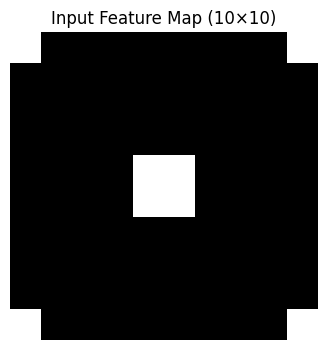

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)

# 构建 1×1×10×10 的输入（batch=1, channel=1, H=10, W=10）
input_tensor = torch.zeros(1, 1, 10, 10)
# 中心亮斑（坐标 (4,4)~(5,5)）
input_tensor[0, 0, 4:6, 4:6] = 1.0
# 四角亮斑（每个角 1×1 像素）
input_tensor[0, 0, 0, 0] = 1.0
input_tensor[0, 0, 0, 9] = 1.0
input_tensor[0, 0, 9, 0] = 1.0
input_tensor[0, 0, 9, 9] = 1.0

# 可视化输入
plt.figure(figsize=(4,4))
plt.imshow(input_tensor.squeeze().numpy(), cmap='gray')
plt.title("Input Feature Map (10×10)")
plt.axis('off')
plt.show()

In [2]:
class ConvExperiment(nn.Module):
    def __init__(self, dilation=1):
        super().__init__()
        # 单通道输入→单通道输出，3×3卷积核，stride=1，padding=1（保证输出尺寸与输入一致）
        self.conv = nn.Conv2d(
            in_channels=1,
            out_channels=1,
            kernel_size=3,
            stride=1,
            padding=1,
            dilation=dilation,  # 空洞率（核心变量）
            bias=False  # 禁用偏置，简化计算
        )
        # 初始化卷积核为全1（便于观察感受野覆盖范围）
        nn.init.constant_(self.conv.weight, 1.0)
    
    def forward(self, x):
        return self.conv(x)

# 初始化3个模型：普通卷积（d=1）、空洞卷积d=2、空洞卷积d=3
model_d1 = ConvExperiment(dilation=1)  # 普通卷积
model_d2 = ConvExperiment(dilation=2)  # 空洞卷积d=2
model_d3 = ConvExperiment(dilation=3)  # 空洞卷积d=3

In [3]:
# 前向传播（关闭梯度计算，提升效率）
with torch.no_grad():
    output_d1 = model_d1(input_tensor)
    output_d2 = model_d2(input_tensor)
    output_d3 = model_d3(input_tensor)

# 转换为numpy数组（便于可视化）
output_d1_np = output_d1.squeeze().numpy()
output_d2_np = output_d2.squeeze().numpy()
output_d3_np = output_d3.squeeze().numpy()

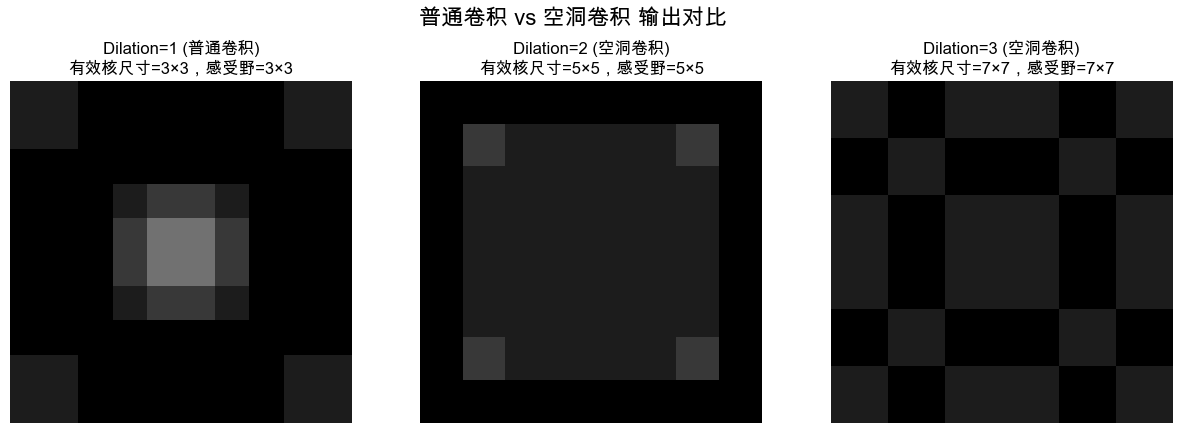

In [4]:
# 创建子图对比
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# MAC中文字体支持
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']

# 普通卷积（d=1）
axes[0].imshow(output_d1_np, cmap='gray', vmin=0, vmax=9)  # 最大输出=3×3=9
axes[0].set_title(f"Dilation=1 (普通卷积)\n有效核尺寸=3×3，感受野=3×3")
axes[0].axis('off')

# 空洞卷积（d=2）
axes[1].imshow(output_d2_np, cmap='gray', vmin=0, vmax=9)
axes[1].set_title(f"Dilation=2 (空洞卷积)\n有效核尺寸=5×5，感受野=5×5")
axes[1].axis('off')

# 空洞卷积（d=3）
axes[2].imshow(output_d3_np, cmap='gray', vmin=0, vmax=9)
axes[2].set_title(f"Dilation=3 (空洞卷积)\n有效核尺寸=7×7，感受野=7×7")
axes[2].axis('off')

plt.suptitle("普通卷积 vs 空洞卷积 输出对比", fontsize=16)
plt.show()

- 有效感受野: $k + (k-1)(d-1) = kd - d + 1$
```
W_out = (W_in + 2 * padding - k_size) // stride + 1
```
- 不改变大小需要的padding: $2 * padding = k' -1 = kd - d$

In [5]:
def count_params(model):
    """计算模型参数量"""
    return sum(p.numel() for p in model.parameters())

print(f"普通卷积（d=1）参数量：{count_params(model_d1)}")
print(f"空洞卷积（d=2）参数量：{count_params(model_d2)}")
print(f"空洞卷积（d=3）参数量：{count_params(model_d3)}")

普通卷积（d=1）参数量：9
空洞卷积（d=2）参数量：9
空洞卷积（d=3）参数量：9


## 空洞卷积和更大卷积核的等价性

In [6]:
import torch
import torch.nn as nn
import numpy as np

# 实验配置
kernel_size = 3  # 原始卷积核尺寸
dilation_list = [2, 3]  # 待验证的空洞率
input_size = 10  # 输入特征图尺寸（1×1×10×10）
padding = 1  # 与之前实验保持一致，保证输出尺寸不变
stride = 1
np.random.seed(42)

In [7]:
from tool import create_equivalent_conv_kernel

class DilatedConv(nn.Module):
    def __init__(self, orig_kernel, dilation):
        super().__init__()
        # 空洞卷积层（使用原始核）
        self.dilated_conv = nn.Conv2d(
            in_channels=1, out_channels=1,
            kernel_size=kernel_size, stride=stride,
            padding=padding, dilation=dilation, bias=False
        )
        # 加载原始权重
        self.dilated_conv.weight.data = torch.tensor(orig_kernel).unsqueeze(0).unsqueeze(0).float()

    def forward(self, x):
        return self.dilated_conv(x)

class EquivalentConv(nn.Module):
    def __init__(self, eq_kernel):
        super().__init__()
        # 普通卷积层（使用手动构造的等价核）
        k_eff = eq_kernel.shape[0]
        self.eq_conv = nn.Conv2d(
            in_channels=1, out_channels=1,
            kernel_size=k_eff, stride=stride,
            padding=padding, dilation=1, bias=False  # 普通卷积（d=1）
        )
        # 加载等价权重
        self.eq_conv.weight.data = torch.tensor(eq_kernel).unsqueeze(0).unsqueeze(0).float()

    def forward(self, x):
        return self.eq_conv(x)

In [8]:
# 生成随机原始3×3卷积核（模拟真实权重，避免全1简化）
orig_kernel = np.random.randn(kernel_size, kernel_size)  # 3×3随机权重
print("原始3×3卷积核：")
print(np.round(orig_kernel, 2))

# 生成随机输入（1×1×10×10）
input_tensor = torch.randn(1, 1, input_size, input_size)

# 对每个空洞率验证等价性
for d in dilation_list:
    print(f"\n=== 验证 dilation={d} 的等价性 ===")
    
    # 1. 构造等价普通卷积核
    eq_kernel = create_equivalent_conv_kernel(orig_kernel, d)
    k_eff = eq_kernel.shape[0]
    print(f"等价普通卷积核尺寸：{k_eff}×{k_eff}")
    print("等价普通卷积核（非零位置对应原始核）：")
    print(np.round(eq_kernel, 2))
    
    # 2. 初始化两个模型
    dilated_model = DilatedConv(orig_kernel, d)
    eq_model = EquivalentConv(eq_kernel)
    
    # 3. 前向传播（关闭梯度）
    with torch.no_grad():
        dilated_output = dilated_model(input_tensor)
        eq_output = eq_model(input_tensor)
    
    # 4. 计算输出差异（验证等价性）
    output_diff = torch.abs(dilated_output - eq_output).max().item()
    print(f"空洞卷积与等价普通卷积的最大输出差异：{output_diff:.8f}")
    
    # 结论
    if output_diff < 1e-6:  # 数值误差可忽略
        print(f"✅ 验证通过！dilation={d} 的3×3空洞卷积 与 {k_eff}×{k_eff}稀疏普通卷积完全等价")
    else:
        print(f"❌ 验证失败！存在明显差异")

原始3×3卷积核：
[[ 0.5  -0.14  0.65]
 [ 1.52 -0.23 -0.23]
 [ 1.58  0.77 -0.47]]

=== 验证 dilation=2 的等价性 ===
等价普通卷积核尺寸：5×5
等价普通卷积核（非零位置对应原始核）：
[[ 0.5   0.   -0.14  0.    0.65]
 [ 0.    0.    0.    0.    0.  ]
 [ 1.52  0.   -0.23  0.   -0.23]
 [ 0.    0.    0.    0.    0.  ]
 [ 1.58  0.    0.77  0.   -0.47]]
空洞卷积与等价普通卷积的最大输出差异：0.00000048
✅ 验证通过！dilation=2 的3×3空洞卷积 与 5×5稀疏普通卷积完全等价

=== 验证 dilation=3 的等价性 ===
等价普通卷积核尺寸：7×7
等价普通卷积核（非零位置对应原始核）：
[[ 0.5   0.    0.   -0.14  0.    0.    0.65]
 [ 0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.  ]
 [ 1.52  0.    0.   -0.23  0.    0.   -0.23]
 [ 0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.  ]
 [ 1.58  0.    0.    0.77  0.    0.   -0.47]]
空洞卷积与等价普通卷积的最大输出差异：0.00000000
✅ 验证通过！dilation=3 的3×3空洞卷积 与 7×7稀疏普通卷积完全等价
